In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import torch
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import warnings
import gc
import matplotlib.pyplot as plt # plot distribution
from sklearn.preprocessing import StandardScaler # Standarded
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Evaluate metrics
from sklearn.linear_model import SGDClassifier # SVM
from sklearn.neural_network import MLPClassifier # MLP
from lightgbm import LGBMClassifier # LightGBM
from sklearn.decomposition import PCA
# preprocessing & HOG extract feature
from skimage.feature import hog
from skimage.transform import resize
# learning curve
from scipy.ndimage import uniform_filter1d
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from collections import Counter
from matplotlib.backends.backend_pdf import PdfPages # Save image as pdf

Data Source: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset

In [ ]:
# Connect to Google Drive
drive.mount('/content/drive')
zip_image = "/content/drive/MyDrive/comp90051 project/share data/celeba_subset.zip"
zip_attr  = "/content/drive/MyDrive/comp90051 project/share data/list_attr_celeba.csv.zip"
extract_image_dir = "/content/images"
extract_csv_dir = "/content"

os.makedirs(extract_image_dir, exist_ok=True)
print("Start decompressing the file...")

!unzip -o -q "$zip_image" -d "$extract_image_dir"
!unzip -o -q "$zip_attr" -d "$extract_csv_dir"
print("Decompression completed！")
print("\n Check the decompressed file：")
!find /content -maxdepth 3 -type f -name "*.csv"
print("\n Check the number of pictures：")
!find /content/images -type f | wc -l

Mounted at /content/drive
Start decompressing the file...
Decompression completed！

 Check the decompressed file：
/content/list_attr_celeba.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_test.csv

 Check the number of pictures：
12000


## Loading and Match Dataset

In [ ]:
# Check dataset
img_dir = "/content/images"
print("number of image:", len(os.listdir(img_dir)))
print("example:", os.listdir(img_dir)[:5])
attr_path = "/content/list_attr_celeba.csv"
df_attr = pd.read_csv(attr_path)
print(df_attr.shape)
df_attr.head()

number of image: 12000
example: ['199595.jpg', '028190.jpg', '044371.jpg', '125606.jpg', '102651.jpg']
(202599, 41)


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [ ]:
# Filter the matching 12000 rows based on image_id
img_dir = "/content/images"
img_files = set(os.listdir(img_dir))
df_subset = df_attr[df_attr["image_id"].isin(img_files)].reset_index(drop=True)
print("matched samples:", len(df_subset))
print(df_subset.shape)
df_subset.head() # Final dataset that we used

matched samples: 12000
(12000, 41)


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000013.jpg,-1,-1,-1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
1,000026.jpg,-1,-1,1,-1,-1,-1,1,-1,-1,...,-1,-1,1,-1,-1,-1,1,-1,-1,1
2,000029.jpg,-1,1,1,-1,-1,1,-1,-1,-1,...,-1,1,-1,1,1,-1,1,-1,-1,1
3,000037.jpg,-1,-1,-1,-1,-1,-1,1,1,-1,...,1,-1,-1,-1,-1,1,-1,-1,-1,1
4,000048.jpg,-1,-1,-1,-1,-1,1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,-1,-1,-1,1


## Step1: Feature Construction & Preprocessing

In [ ]:
# Custom Augmentation for Random Occlusion
class RandomOcclusion:
    def __init__(self, p=1.0, scale=(0.05, 0.2), ratio=(0.5, 2.0)):
        self.p = p # Probability of applying occlusion
        self.scale = scale # Range of occluded area (as a fraction of total image)
        self.ratio = ratio # Range of aspect ratios (width/height)
    def __call__(self, img):
        if np.random.rand() > self.p: # Skip augmentation with prob(1 - p)
            return img
        img_np = np.array(img)
        h, w, c = img_np.shape
        area = h * w
        # Randomly sample occlusion size and shape
        occlusion_area = np.random.uniform(self.scale[0], self.scale[1]) * area
        aspect_ratio = np.random.uniform(self.ratio[0], self.ratio[1])
        occ_h = int(round(np.sqrt(occlusion_area * aspect_ratio)))
        occ_w = int(round(np.sqrt(occlusion_area / aspect_ratio)))
        # Randomly place black patch
        if occ_w < w and occ_h < h:
            top = np.random.randint(0, h - occ_h)
            left = np.random.randint(0, w - occ_w)
            img_np[top:top + occ_h, left:left + occ_w, :] = 0
        return Image.fromarray(img_np)

# HOG Feature Extraction
def extract_hog_features(image_dir, df, sample_size=10000, image_size=(64, 128), augmentations=None):
    # Extract Histogram of Oriented Gradients (HOG) features from a sample of images
    image_ids_to_process = df["image_id"].values[:sample_size]
    features_list = []
    processed_image_ids = []

    aug_name = "Original" if augmentations is None else "Occluded"
    print(f"Starting HOG extraction for {len(image_ids_to_process)} '{aug_name}' images...")
    # Loop through sampled image
    for img_id in tqdm(image_ids_to_process, desc=f"Extracting ({aug_name}) HOG"):
        img_path = os.path.join(image_dir, img_id)
        if not os.path.exists(img_path):
            continue
        try:
            image_rgb = Image.open(img_path).convert('RGB')
            if augmentations:
                image_rgb = augmentations(image_rgb)
            image_gray = image_rgb.convert('L') # Convert to grayscale
            image_resized = np.array(image_gray.resize(image_size))
            hog_feature = hog(image_resized, orientations=9, pixels_per_cell=(8, 8),
                              cells_per_block=(2, 2), visualize=False, block_norm='L2-Hys')
            features_list.append(hog_feature)
            processed_image_ids.append(img_id)
        except Exception as e:
            print(f"Error processing image {img_id}: {e}")

    features_array = np.array(features_list)# Stack features into a single matrix
    print(f"\nFeature extraction complete for '{aug_name}' images.")
    print(f"Processed {features_array.shape[0]} images.")
    print(f"HOG Feature matrix shape: {features_array.shape}\n")
    return features_array, processed_image_ids

# Original(unaltered)features
X_original, processed_ids = extract_hog_features(img_dir, df_subset, sample_size=10000, augmentations=None)

# Occluded feature(random occlusions applied)
occlusion_pipeline = transforms.Compose([RandomOcclusion(p=1.0, scale=(0.05, 0.2))])
X_occluded, _ = extract_hog_features(img_dir, df_subset, sample_size=10000, augmentations=occlusion_pipeline)

# Label Preparation
df_subset = df_subset[df_subset["image_id"].isin(processed_ids)].reset_index(drop=True)
target_labels = ['Smiling', 'High_Cheekbones'] # Binary target attributes
Y = (df_subset[target_labels].values == 1).astype(int)
Y = pd.DataFrame(Y, columns=target_labels)
X = X_occluded # Use occluded feature set for modeling

print(f"original feature matrix: {X_original.shape}")
print(f"occluded feature matrix: {X_occluded.shape}")
print(f"label DataFrame: {Y.shape}")

del X_original
gc.collect()
if 'X_original' in locals() or 'X_original' in globals():
    print("X_original still in memory")
else:
    print("X_original has been successfully deleted")

Starting HOG extraction for 10000 'Original' images...


Extracting (Original) HOG: 100%|██████████| 10000/10000 [00:43<00:00, 230.19it/s]



Feature extraction complete for 'Original' images.
Processed 10000 images.
HOG Feature matrix shape: (10000, 3780)

Starting HOG extraction for 10000 'Occluded' images...


Extracting (Occluded) HOG: 100%|██████████| 10000/10000 [00:40<00:00, 244.65it/s]



Feature extraction complete for 'Occluded' images.
Processed 10000 images.
HOG Feature matrix shape: (10000, 3780)

original feature matrix: (10000, 3780)
occluded feature matrix: (10000, 3780)
label DataFrame: (10000, 2)
X_original has been successfully deleted


## Step2: Model Training and Evaluation

### Nested - 10 fold cross validation & Hyperparameter tuning

In [ ]:
# Manually 10-fold indices for cv
def manual_kfold_indices(n_samples, k=10, random_state=42):
    np.random.seed(random_state)
    indices = np.random.permutation(n_samples) # Shuffle all sample indices
    fold_sizes = np.full(k, n_samples // k, dtype=int) # Base size for each fold
    fold_sizes[:n_samples % k] += 1 # Distribute any extra samples evenly
    folds, current = [], 0
    for fold_size in fold_sizes:
        folds.append(indices[current:current + fold_size]) # Slice indices for this fold
        current += fold_size
    return folds
# Standardize features using training set
def manual_standardize(X_train, X_test):
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1e-8  # Prevent division by zero
    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std

def manual_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    acc = (tp + tn) / len(y_true)
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    return acc, prec, rec, f1

In [ ]:
# Nested Cross-Validation with Manual 10-Fold and PCA
def nested_cv_metrics(X, y, outer_folds, model_builder_fn, param_grid, standardize=True, inner_k=3):
    outer_acc, outer_prec, outer_rec, outer_f1 = [], [], [], []
    inner_train_accs = []  # Average training accuracy for each outer fold
    acc_folds = [] # verification accuracy of an outer fold
    outer_best_params = [] # Record best hyperparameter for each outer fold
    # Outer loop for evaluate
    for i, test_idx in enumerate(outer_folds):
        print(f"\n Outer Fold {i+1}/{len(outer_folds)}")
        # Split data into training and testing sets
        train_idx = np.setdiff1d(np.arange(len(X)), test_idx)
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        X_train = np.array(X_train)
        X_test = np.array(X_test)

        # Inner loop for hyperparameter tuning
        inner_folds = manual_kfold_indices(len(train_idx), k=inner_k)
        best_param, best_score = None, -np.inf
        best_inner_train_acc = 0  # Record average accuracy of best param training set
        for param in param_grid:
            acc_list = []
            for inner_idx in range(inner_k):
                val_idx = inner_folds[inner_idx]
                tr_idx = np.concatenate([inner_folds[j] for j in range(inner_k) if j != inner_idx])
                X_tr, X_val = X_train[tr_idx], X_train[val_idx]
                y_tr, y_val = y_train[tr_idx], y_train[val_idx]

                # Standardize features using only training statistics
                if standardize:
                    X_tr, X_val = manual_standardize(X_tr, X_val)
                # PCA only on training set
                pca = PCA(n_components=100, random_state=42)
                X_tr = pca.fit_transform(X_tr)
                X_val = pca.transform(X_val)

                # Train model and evaluate on validation fold
                model = model_builder_fn(param) # Build model using current hyperparameter
                model.fit(np.asarray(X_tr), np.asarray(y_tr)) # Fit model on inner training subset
                y_pred = model.predict(np.asarray(X_val))
                acc, _, _, _ = manual_metrics(y_val, y_pred) # Compute validation accuracy (ignore other metrics)
                acc_list.append(acc) # Save accuracy score

            # Select best hyperparameters based on validation accuracy
            mean_acc = np.mean(acc_list)
            if mean_acc > best_score:
                best_score, best_param = mean_acc, param
                best_inner_train_acc = np.mean(acc_list)  # Save inner layer accuracy of best param training set
        print(f" Best param: {best_param}, inner mean acc={best_score:.3f}")
        inner_train_accs.append(best_inner_train_acc)  # Save inner layer training accuracy to list
        outer_best_params.append(best_param)
        # Outer evaluation using best parameters
        if standardize:
            X_train_std, X_test_std = manual_standardize(X_train, X_test)
        else:
            X_train_std, X_test_std = X_train, X_test

        pca = PCA(n_components=100, random_state=42)
        X_train_pca = pca.fit_transform(X_train_std)
        X_test_pca = pca.transform(X_test_std)
        # Train best model on full training set and test on outer fold
        best_model = model_builder_fn(best_param)
        best_model.fit(np.asarray(X_train_pca), np.asarray(y_train))
        y_pred = best_model.predict(np.asarray(X_test_pca))

        acc, prec, rec, f1 = manual_metrics(y_test, y_pred)
        outer_acc.append(acc)
        outer_prec.append(prec)
        outer_rec.append(rec)
        outer_f1.append(f1)
        acc_folds.append(acc)
        print(f" Outer Fold {i+1} Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}")

    most_common_param = Counter(tuple(sorted(p.items())) for p in outer_best_params).most_common(1)[0][0]
    most_common_param = dict(most_common_param)
    return {
        "Accuracy (mean)": np.mean(outer_acc), "Accuracy (std)": np.std(outer_acc),
        "Precision (mean)": np.mean(outer_prec), "Precision (std)": np.std(outer_prec),
        "Recall (mean)": np.mean(outer_rec), "Recall (std)": np.std(outer_rec),
        "F1 (mean)": np.mean(outer_f1), "F1 (std)": np.std(outer_f1),
        "Best Param": most_common_param,
        "Train Acc (inner)": inner_train_accs,  # Save average training accuracy corresponding to each fold
        "Acc Folds": acc_folds
    }
# Shared folds across all models for fair comparison
folds_shared = manual_kfold_indices(len(X), k=10, random_state=42)

### 1) Simple Model: Linear SVM (SGD classifier)

In [ ]:
# Linear SVM (SGD Classifier )
def run_linear_svm_nested(X, y, folds):
    param_grid = [{"alpha": a} for a in [0.01, 1, 10]]
    def builder(p):
        return SGDClassifier(loss="hinge", alpha=p["alpha"], penalty="l2", # L2 regularization
            class_weight="balanced", # Handle unbalanced labels
            max_iter=400, # Reduce the number of iterations
            tol=1e-3, # convergence threshold
            n_jobs=-1,# parallel computation
            random_state=42
        )
    # Run nested cv with inner/outer loops
    return nested_cv_metrics(X=X, y=y, outer_folds=folds, inner_k=3,
                             model_builder_fn=builder, param_grid=param_grid, standardize=True
                             )
# Run Linear SVM model for each target attribute
results_linear_svm = {}
for label in Y.columns:
    print(f"Attribute: {label}")
    y = Y[label].values
    results_linear_svm[label] = run_linear_svm_nested(X, y, folds_shared)

# Convert results into DataFrame
df_linear_svm = pd.DataFrame(results_linear_svm).T

# Format results (mean ± std)
def format_mean_std(mean_series, std_series):
    return mean_series.map(lambda x: f"{x:.3f}") + " ± " + std_series.map(lambda x: f"{x:.3f}")
df_linear_svm_pretty = pd.DataFrame({
    "Accuracy": format_mean_std(df_linear_svm["Accuracy (mean)"], df_linear_svm["Accuracy (std)"]),
    "Precision": format_mean_std(df_linear_svm["Precision (mean)"], df_linear_svm["Precision (std)"]),
    "Recall": format_mean_std(df_linear_svm["Recall (mean)"], df_linear_svm["Recall (std)"]),
    "F1": format_mean_std(df_linear_svm["F1 (mean)"], df_linear_svm["F1 (std)"])
})
print("\n Linear SVM (SGDClassifier) Nested CV Results ")
print(df_linear_svm_pretty.to_string())

Attribute: Smiling

 Outer Fold 1/10
 Best param: {'alpha': 1}, inner mean acc=0.795
 Outer Fold 1 Acc=0.804, Prec=0.805, Rec=0.756, F1=0.780

 Outer Fold 2/10
 Best param: {'alpha': 1}, inner mean acc=0.792
 Outer Fold 2 Acc=0.788, Prec=0.721, Rec=0.873, F1=0.789

 Outer Fold 3/10
 Best param: {'alpha': 1}, inner mean acc=0.793
 Outer Fold 3 Acc=0.808, Prec=0.783, Rec=0.832, F1=0.807

 Outer Fold 4/10
 Best param: {'alpha': 1}, inner mean acc=0.794
 Outer Fold 4 Acc=0.790, Prec=0.749, Rec=0.851, F1=0.797

 Outer Fold 5/10
 Best param: {'alpha': 1}, inner mean acc=0.793
 Outer Fold 5 Acc=0.819, Prec=0.854, Rec=0.739, F1=0.793

 Outer Fold 6/10
 Best param: {'alpha': 1}, inner mean acc=0.794
 Outer Fold 6 Acc=0.800, Prec=0.769, Rec=0.830, F1=0.798

 Outer Fold 7/10
 Best param: {'alpha': 1}, inner mean acc=0.796
 Outer Fold 7 Acc=0.798, Prec=0.791, Rec=0.781, F1=0.786

 Outer Fold 8/10
 Best param: {'alpha': 1}, inner mean acc=0.791
 Outer Fold 8 Acc=0.792, Prec=0.750, Rec=0.852, F1=0.7

### 2) Medium Model: MLP

In [ ]:
# Multilayer Perceptron (MLP Neural Network)
def run_mlp_nested(X, y, folds):
    param_grid = [
        {"hidden_layer_sizes": (128, 64), "alpha": a, "learning_rate_init": 0.001}
        for a in [0.0001, 0.001, 0.01]
    ]
    def builder(p):
        return MLPClassifier(hidden_layer_sizes=(128, 64), alpha=p["alpha"], learning_rate_init=1e-3,
                             activation="relu", # Standard nonlinear activation
                             solver="adam", # Estimation optimizer
                             max_iter=150, batch_size=256, # Limit iterations to prevent long training
                             early_stopping=True, n_iter_no_change=5, # Stop when validation score stops improving
                             tol=1e-3, # Convergence tolerance
                             random_state=42,verbose=False
                             )
    # Run nested cross-validation
    return nested_cv_metrics(X=X, y=y, outer_folds=folds, inner_k=3,
                             model_builder_fn=builder, param_grid=param_grid, standardize=True
                             )
# Run MLP model
results_mlp = {}
for label in Y.columns:
    print(f"Attribute: {label}")
    y = Y[label].values
    results_mlp[label] = run_mlp_nested(X, y, folds_shared)

# Convert results into DataFrame
df_mlp = pd.DataFrame(results_mlp).T
df_mlp_pretty = pd.DataFrame({
    "Accuracy": format_mean_std(df_mlp["Accuracy (mean)"], df_mlp["Accuracy (std)"]),
    "Precision": format_mean_std(df_mlp["Precision (mean)"], df_mlp["Precision (std)"]),
    "Recall": format_mean_std(df_mlp["Recall (mean)"], df_mlp["Recall (std)"]),
    "F1": format_mean_std(df_mlp["F1 (mean)"], df_mlp["F1 (std)"])
})
print("\n Optimized MLP (Neural Network) Nested CV Results ")
print(df_mlp_pretty.to_string())

Attribute: Smiling

 Outer Fold 1/10
 Best param: {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}, inner mean acc=0.772
 Outer Fold 1 Acc=0.776, Prec=0.762, Rec=0.745, F1=0.753

 Outer Fold 2/10
 Best param: {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}, inner mean acc=0.777
 Outer Fold 2 Acc=0.803, Prec=0.784, Rec=0.782, F1=0.783

 Outer Fold 3/10
 Best param: {'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'learning_rate_init': 0.001}, inner mean acc=0.774
 Outer Fold 3 Acc=0.783, Prec=0.775, Rec=0.774, F1=0.775

 Outer Fold 4/10
 Best param: {'hidden_layer_sizes': (128, 64), 'alpha': 0.01, 'learning_rate_init': 0.001}, inner mean acc=0.775
 Outer Fold 4 Acc=0.774, Prec=0.760, Rec=0.779, F1=0.769

 Outer Fold 5/10
 Best param: {'hidden_layer_sizes': (128, 64), 'alpha': 0.0001, 'learning_rate_init': 0.001}, inner mean acc=0.770
 Outer Fold 5 Acc=0.785, Prec=0.773, Rec=0.765, F1=0.769

 Outer Fold 6/10
 Best param: {'h

### 3) Complex Model: LightGBM

In [ ]:
# LightGBM
warnings.filterwarnings("ignore", category=UserWarning)
use_gpu = torch.cuda.is_available() # Detect GPU availability
print(f"LightGBM device: {'GPU' if use_gpu else 'CPU'}")

def run_lgbm_nested(X, y, folds):
    param_grid = [
        {"n_estimators": 100, "learning_rate": 0.1},
        {"n_estimators": 200, "learning_rate": 0.05},
        {"n_estimators": 300, "learning_rate": 0.01}
    ]
    def builder(p):
        return LGBMClassifier(n_estimators=p["n_estimators"], learning_rate=p["learning_rate"],
                              max_depth=-1, # No limit on tree depth
                              subsample=0.8, feature_fraction=0.8, # Row and Column sampling for regularization
                              objective='binary', class_weight='balanced',
                              n_jobs=-1,# Parallel computation
                              device_type="gpu" if use_gpu else "cpu",
                              random_state=42,verbosity=-1
                              )
    # Run nested cross-validation
    return nested_cv_metrics(X=X, y=y, outer_folds=folds, inner_k=3,
                              model_builder_fn=builder, param_grid=param_grid,
                              standardize=False # tree model don't need standardize
                             )
# Run LightGBM nested CV
results_lgbm = {}
for label in Y.columns:
    print(f"Attribute: {label}")
    y = Y[label].values
    # Record results for each label
    results_lgbm[label] = run_lgbm_nested(X, y, folds_shared)

# Convert results into a DataFrame
df_lgbm = pd.DataFrame(results_lgbm).T
df_lgbm_pretty = pd.DataFrame({
    'Accuracy': format_mean_std(df_lgbm['Accuracy (mean)'], df_lgbm['Accuracy (std)']),
    'Precision': format_mean_std(df_lgbm['Precision (mean)'], df_lgbm['Precision (std)']),
    'Recall': format_mean_std(df_lgbm['Recall (mean)'], df_lgbm['Recall (std)']),
    'F1': format_mean_std(df_lgbm['F1 (mean)'], df_lgbm['F1 (std)'])
})
print("\n LightGBM Nested CV Results ")
print(df_lgbm_pretty.to_string())

LightGBM device: GPU
Attribute: Smiling

 Outer Fold 1/10
 Best param: {'n_estimators': 200, 'learning_rate': 0.05}, inner mean acc=0.757
 Outer Fold 1 Acc=0.759, Prec=0.739, Rec=0.734, F1=0.737

 Outer Fold 2/10
 Best param: {'n_estimators': 200, 'learning_rate': 0.05}, inner mean acc=0.751
 Outer Fold 2 Acc=0.764, Prec=0.737, Rec=0.749, F1=0.743

 Outer Fold 3/10
 Best param: {'n_estimators': 200, 'learning_rate': 0.05}, inner mean acc=0.762
 Outer Fold 3 Acc=0.769, Prec=0.764, Rec=0.753, F1=0.759

 Outer Fold 4/10
 Best param: {'n_estimators': 200, 'learning_rate': 0.05}, inner mean acc=0.753
 Outer Fold 4 Acc=0.774, Prec=0.776, Rec=0.750, F1=0.763

 Outer Fold 5/10
 Best param: {'n_estimators': 200, 'learning_rate': 0.05}, inner mean acc=0.747
 Outer Fold 5 Acc=0.778, Prec=0.777, Rec=0.737, F1=0.757

 Outer Fold 6/10
 Best param: {'n_estimators': 200, 'learning_rate': 0.05}, inner mean acc=0.746
 Outer Fold 6 Acc=0.766, Prec=0.764, Rec=0.738, F1=0.751

 Outer Fold 7/10
 Best param:

In [ ]:
# Best Hyperparameters Selected
print(" Best Hyperparameters Selected in Nested CV")
# Linear SVM
print("Linear SVM (SGDClassifier):")
for label in Y.columns:
    print(f" Label '{label}': {results_linear_svm[label]['Best Param']}")
print()
# MLP
print("MLP (Neural Network):")
for label in Y.columns:
    print(f" Label '{label}': {results_mlp[label]['Best Param']}")
print()
# LightGBM
print("LightGBM:")
for label in Y.columns:
    print(f" Label '{label}': {results_lgbm[label]['Best Param']}")

 Best Hyperparameters Selected in Nested CV
Linear SVM (SGDClassifier):
 Label 'Smiling': {'alpha': 1}
 Label 'High_Cheekbones': {'alpha': 1}

MLP (Neural Network):
 Label 'Smiling': {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
 Label 'High_Cheekbones': {'alpha': 0.001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}

LightGBM:
 Label 'Smiling': {'learning_rate': 0.05, 'n_estimators': 200}
 Label 'High_Cheekbones': {'learning_rate': 0.05, 'n_estimators': 200}


In [ ]:
# Summarize the results of the three models on two labels
df_linear_svm_pretty["Model"] = "Linear SVM"
df_mlp_pretty["Model"] = "MLP"
df_lgbm_pretty["Model"] = "LightGBM"
df_linear_svm_pretty["Label"] = df_linear_svm_pretty.index
df_mlp_pretty["Label"] = df_mlp_pretty.index
df_lgbm_pretty["Label"] = df_lgbm_pretty.index

df_all_models = pd.concat([df_linear_svm_pretty, df_mlp_pretty, df_lgbm_pretty], axis=0)
df_all_models = df_all_models[["Label", "Model", "Accuracy", "Precision", "Recall", "F1"]]
print("\n Combined Results of All Models (per Label)")
print(df_all_models.to_string(index=False))


 Combined Results of All Models (per Label)
          Label      Model      Accuracy     Precision        Recall            F1
        Smiling Linear SVM 0.796 ± 0.011 0.780 ± 0.044 0.804 ± 0.054 0.789 ± 0.012
High_Cheekbones Linear SVM 0.749 ± 0.011 0.712 ± 0.023 0.736 ± 0.056 0.722 ± 0.019
        Smiling        MLP 0.779 ± 0.014 0.773 ± 0.010 0.757 ± 0.027 0.764 ± 0.016
High_Cheekbones        MLP 0.730 ± 0.016 0.708 ± 0.029 0.669 ± 0.031 0.687 ± 0.019
        Smiling   LightGBM 0.764 ± 0.009 0.756 ± 0.016 0.742 ± 0.012 0.749 ± 0.012
High_Cheekbones   LightGBM 0.719 ± 0.014 0.686 ± 0.016 0.674 ± 0.016 0.680 ± 0.014


## Step3: Error Bar & learning curve

Saved Image to: /content/drive/MyDrive/comp90051 project/share data/error_bar.png


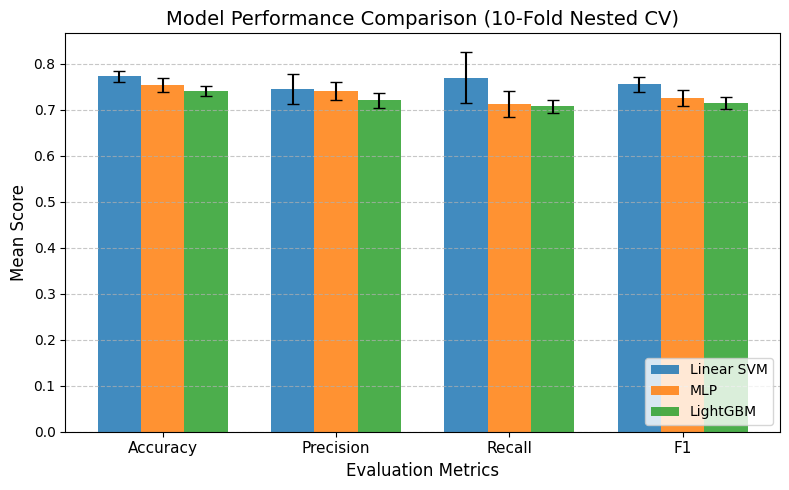

In [ ]:
# Model Performance Comparison (Linear SVM vs MLP vs LightGBM)
models = ['Linear SVM', 'MLP', 'LightGBM']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
# Store model result DataFrames
df_dict = {'Linear SVM': df_linear_svm, 'MLP': df_mlp, 'LightGBM': df_lgbm}
# Compute mean and sd
summary = {}
for model_name, df in df_dict.items():
    means = [df[f"{m} (mean)"].mean() for m in metrics]
    stds  = [df[f"{m} (std)"].mean()  for m in metrics]
    summary[model_name] = (means, stds)

x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
for i, model_name in enumerate(models):
    means, stds = summary[model_name]
    ax.bar(x + i*width, means, width, yerr=stds, label=model_name, capsize=4, alpha=0.85)

ax.set_xlabel('Evaluation Metrics', fontsize=12)
ax.set_ylabel('Mean Score', fontsize=12)
ax.set_title('Model Performance Comparison (10-Fold Nested CV)', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

save_path = "/content/drive/MyDrive/comp90051 project/share data/error_bar.png"
alter_path = "/content/error_bar.png"
try:
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved Image to: {save_path}")
except Exception:
    plt.savefig(alter_path, dpi=300, bbox_inches='tight')
    print(f"Cannot save locally. Save to: {alter_path}")
plt.show()


## Learning curve

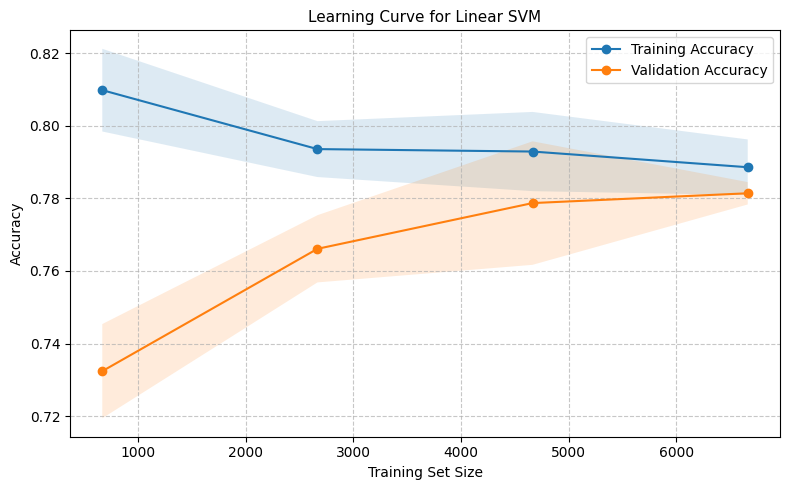

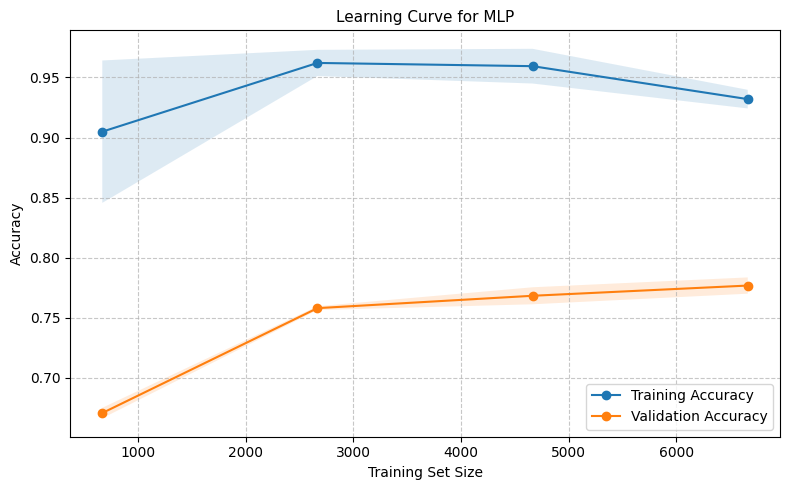

LightGBM device: GPU


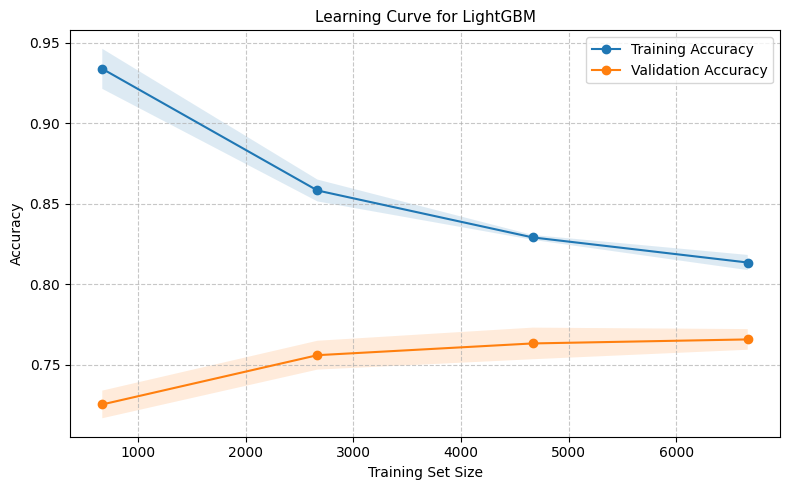

In [ ]:
# learning curve
save_path = "/content/drive/MyDrive/comp90051 project/share data/learning_curves1.pdf"
alter_path = "/content/learning_curves1.pdf"
try:
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    pdf_path = save_path
except Exception:
    pdf_path = alter_path
    print(f"Cannot save locally. Save to: {pdf_path}")

with PdfPages(pdf_path) as pdf:
    def plot_learning_curve(model, X, y, title, standardize=True, pca_components=100, cv=3, n_sizes=4):
        steps = []
        if standardize:
            steps.append(('scaler', StandardScaler()))
        if pca_components is not None:
            steps.append(('pca', PCA(n_components=pca_components, random_state=42)))
        steps.append(('model', model))
        pipeline = Pipeline(steps)

        train_sizes, train_scores, test_scores = learning_curve(
            estimator=pipeline,
            X=X, y=y, cv=cv, scoring='accuracy',
            train_sizes=np.linspace(0.1, 1.0, n_sizes),
            n_jobs=-1, shuffle=True
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.figure(figsize=(8,5))
        plt.plot(train_sizes, train_mean, 'o-', label="Training Accuracy")
        plt.plot(train_sizes, test_mean, 'o-', label="Validation Accuracy")
        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15)
        plt.title(title, fontsize=11)
        plt.xlabel("Training Set Size")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        pdf.savefig()
        plt.show()
    # LinearSVM
    svm_model = SGDClassifier(loss="hinge", alpha=0.01, penalty="l2", class_weight="balanced",
                              max_iter=400, tol=1e-3, random_state=42)
    plot_learning_curve(svm_model, X, Y["Smiling"].values,
                        "Learning Curve for Linear SVM", standardize=True, pca_components=100)

    # MLP
    mlp_model = MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu", solver="adam",
                              alpha=0.001, learning_rate_init=0.001,max_iter=150,
                              batch_size=256, early_stopping=True, random_state=42)
    plot_learning_curve(mlp_model, X, Y["Smiling"].values,
                        "Learning Curve for MLP", standardize=True, pca_components=100)

    # LightGBM
    use_gpu = torch.cuda.is_available()
    print(f"LightGBM device: {'GPU' if use_gpu else 'CPU'}")

    lgbm_model = LGBMClassifier(n_estimators=20, learning_rate=0.05, subsample=0.8, feature_fraction=0.8,
                                max_depth=5, num_leaves=15, min_child_samples=50,
                                objective="binary", class_weight="balanced",
                                device_type="gpu" if use_gpu else "cpu", n_jobs=-1, random_state=42, verbosity=-1)
    plot_learning_curve(lgbm_model, X, Y["Smiling"].values,
                        "Learning Curve for LightGBM", standardize=False, pca_components=None)
